# iter5.2 — comic stylization across common geoms

Comic mode renders plots in an XKCD-style hand-drawn look: a deterministic `SineWobble` is applied in pixel space after Douglas-Peucker simplification, so straight lines bend, rectangles ripple, and axis lines wobble — without affecting hit-testing.

There is no public Python API yet (that lands in S03). For now we toggle comic mode by setting `comic: true` on the underlying spec dict via the inherited `FeatureSpec.props()` mutator. The Kotlin layer (`CompositeFigureConfig`) propagates a composite-level `comic` flag to every subplot, so we only need to set it once on the `gggrid` result.

This notebook builds six small plots (one per common geom family), renders them as a 3×2 grid in the default crisp style, then re-renders the same grid with comic mode on for visual comparison.


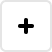
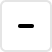
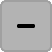
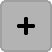
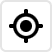
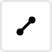
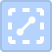
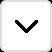
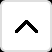
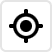
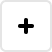
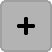
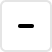
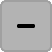
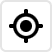
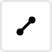
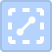
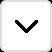
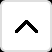
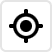

In [1]:
from lets_plot import *

LetsPlot.setup_html()

In [2]:
def comic(spec):
    spec.props()['comic'] = True
    return spec

## Six common geoms

Each plot exercises a distinct wobble-routing path: `LinesHelper` (line/point/ribbon/polygon) and `RectanglesHelper` (bar/boxplot/tile). Cartesian axes, gridlines, and the discrete legend frame wobble in every cell for free.

In [3]:
p_line = ggplot(
    {'x': [0, 1, 2, 3, 4, 5, 6, 7],
     'y': [3, 5, 4, 7, 6, 8, 7, 9]},
    aes('x', 'y')
) + geom_line(size=2, color='steelblue') \
  + geom_point(size=4, color='steelblue') \
  + ggtitle('line + point')

p_bar = ggplot(
    {'cat': ['A', 'B', 'C', 'D', 'E'],
     'val': [4, 7, 3, 8, 5]},
    aes('cat', 'val')
) + geom_bar(stat='identity', fill='#e6550d') \
  + ggtitle('bar')

p_box = ggplot(
    {'g': ['x']*6 + ['y']*6 + ['z']*6,
     'v': [1.1, 1.4, 1.8, 2.0, 2.3, 2.7,
           2.5, 2.9, 3.2, 3.6, 4.0, 4.4,
           0.2, 0.5, 0.9, 1.2, 1.6, 1.9]},
    aes('g', 'v', fill='g')
) + geom_boxplot() \
  + ggtitle('boxplot')

p_tile = ggplot(
    {'x': [i % 5 for i in range(25)],
     'y': [i // 5 for i in range(25)],
     'v': [((i * 7) % 11) / 10.0 for i in range(25)]},
    aes('x', 'y', fill='v')
) + geom_tile() \
  + ggtitle('tile')

p_ribbon = ggplot(
    {'x':   [0, 1, 2, 3, 4, 5, 6, 7],
     'lo':  [1, 2, 1.5, 3, 2.5, 4, 3.5, 5],
     'hi':  [3, 4, 4.5, 6, 5.5, 7, 7.5, 9],
     'mid': [2, 3, 3.0, 4.5, 4.0, 5.5, 5.5, 7]},
    aes('x')
) + geom_ribbon(aes(ymin='lo', ymax='hi'), fill='#4682b4', alpha=0.4) \
  + geom_line(aes(y='mid'), color='#4682b4', size=2) \
  + ggtitle('ribbon')

p_poly = ggplot(
    {'x':  [0, 1, 1, 0,   2, 3, 3, 2,   0.5, 2.5, 1.5],
     'y':  [0, 0, 1, 1,   0, 0, 1, 1,   1.5, 1.5, 2.5],
     'id': ['sq1']*4 + ['sq2']*4 + ['tri']*3},
    aes('x', 'y', group='id', fill='id')
) + geom_polygon(color='black', alpha=0.7) \
  + ggtitle('polygon')

## Composite — crisp

Default rendering. Use this as the visual baseline for comparison with the comic version below.

In [4]:
gggrid([p_line, p_bar, p_box, p_tile, p_ribbon, p_poly], ncol=2)

## Composite — comic

Same six plots; `comic: true` set on the composite figure. Axes, gridlines, rectangle outlines, and stroked lines should visibly wobble. `geom_polygon` and `geom_ribbon` outlines are part of S01 — they will start wobbling once those hook sites land.

In [5]:
comic(gggrid([p_line, p_bar, p_box, p_tile, p_ribbon, p_poly], ncol=2))

## Less-common geoms

Lollipop, area, density, violin, errorbar — regularly used but not in the first composite. Mixed wobble status today: area / density / errorbar wobble (LinesHelper.renderPaths + renderBands hooks, and ErrorBarGeom's `comicStylize.applyLine()` per whisker/stem); lollipop / violin are still crisp under comic and will start wobbling once their iter5.2 S02 hook sites land.


In [6]:
p_lolli = ggplot(
    {'cat': ['A', 'B', 'C', 'D', 'E'],
     'val': [4, 7, 3, 8, 5]},
    aes('cat', 'val')
) + geom_lollipop(color='#e6550d', size=4) \
  + ggtitle('lollipop')

p_area = ggplot(
    {'x': [0, 1, 2, 3, 4, 5, 6, 7],
     'y': [1, 3, 2, 5, 4, 6, 5, 7]},
    aes('x', 'y')
) + geom_area(fill='steelblue', alpha=0.5, color='steelblue') \
  + ggtitle('area')

p_density = ggplot(
    {'v': [1, 1, 2, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 7, 8]},
    aes('v')
) + geom_density(fill='steelblue', alpha=0.5, color='steelblue') \
  + ggtitle('density')

p_violin = ggplot(
    {'g': ['x']*10 + ['y']*10,
     'v': [1, 2, 2, 3, 3, 3, 3, 4, 4, 5,
           3, 4, 4, 5, 5, 5, 5, 6, 6, 7]},
    aes('g', 'v', fill='g')
) + geom_violin() \
  + ggtitle('violin')

p_err = ggplot(
    {'cat':  ['a', 'b', 'c', 'd'],
     'mean': [3.0, 5.0, 4.0, 7.0],
     'lo':   [2.0, 4.0, 3.5, 5.5],
     'hi':   [4.0, 6.0, 4.5, 8.5]},
    aes('cat', 'mean')
) + geom_errorbar(aes(ymin='lo', ymax='hi'), width=0.3) \
  + geom_point(size=4) \
  + ggtitle('errorbar')

p_hex = ggplot(
    {'x': [0.5, 0.7, 1.1, 1.3, 1.6, 1.8, 2.1, 2.4, 2.6, 2.9,
           1.0, 1.2, 1.5, 1.7, 2.0, 2.2, 2.5, 2.8, 3.0, 3.2],
     'y': [1.1, 1.6, 1.3, 1.9, 1.5, 2.1, 1.7, 2.3, 1.9, 2.5,
           2.0, 2.4, 1.8, 2.6, 2.2, 2.8, 2.4, 3.0, 2.6, 3.2]},
    aes('x', 'y')
) + geom_hex(bins=[4, 4], color='white') \
  + ggtitle('hex')


## Composite — crisp

Six less-common geoms in a 3×2 grid, default crisp rendering.

In [7]:
gggrid([p_lolli, p_area, p_density, p_violin, p_err, p_hex], ncol=2)


## Composite — comic

Same five plots with `comic: true` set on the composite. **Wobbled now:** area outline, density curve, errorbar whiskers/stems, plus axes/gridlines on every cell. **Still crisp under comic** until S02 hooks land: lollipop sticks, violin outlines.

In [8]:
comic(gggrid([p_lolli, p_area, p_density, p_violin, p_err, p_hex], ncol=2))
